In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

current_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(current_dir, ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
from utils import *

In [9]:
gt = np.array([0.7055982928920669, 3.156903985518641, 3.156903985518787, 7.153786050761914,
    7.511172985118709, 7.511172985118844, 13.24603636332285, 13.2460363633229,
    13.81180009113035, 13.81180009113066, 21.22903824611463, 21.35005270568866,
    21.35005270568878, 22.07738393899707, 22.07738393899722, 31.26184598886066,
    31.26184598886095, 31.45282245465096, 31.45282245465125, 32.31783085853352
])
num_eigs = len(gt)

In [13]:
np.save('../data/eigs_semi_sphere_fem.npy', gt)

In [ ]:
data = np.load('../data/eigs_semi_sphere_d4.npy')

In [11]:
diff = np.abs(data - gt)[:, :, :]
err_max = np.max(diff, axis=-1)
err_l2 = np.sqrt(np.sum(diff ** 2, axis=-1) / num_eigs)

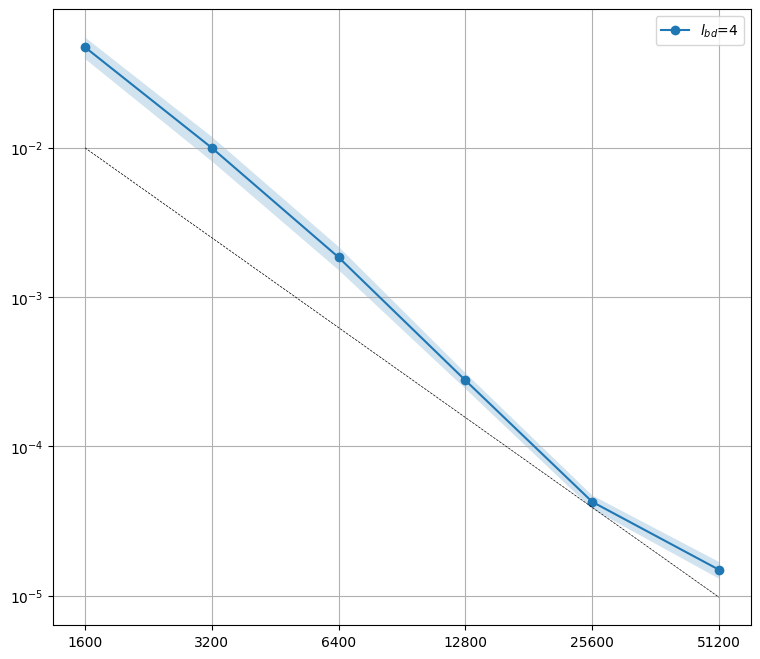

In [12]:
N_vals = [1600, 3200, 6400, 12800, 25600, 51200]

err = err_l2

mean = np.mean(err, axis=1)
std = np.std(err, axis=1)

d2 = {
    'mean': mean,
    'std': std,
    'plot_kwargs': {
        'label': r'$l_{bd}$=4'
    }
}

plot_convergence(N_vals, [d2], ref_list=[
    # ((1600, 2e-3), -1.0, ''),
    # ((1600, 1e-3), -1.5, ''),
    ((1600, 1e-2), -2.0, ''),
])